### Iteration 1 — RQ1: Multilingual Binary Classification with `bert-base-cased`

**Research Question 1:** Can a BERT + SVM pipeline classify process-safety vs. non-process-safety reports with Macro F1 ≥ 0.85?

| Aspect | Detail |
|---|---|
| **Baseline (Iteration 0)** | `bert-base-uncased` + SVM on English-only data → Macro F1 = 0.7825 |
| Switched to **`bert-base-cased`** (preserves capitalisation cues) and extended to **multilingual** country-level datasets (Germany, UK, Sweden, Netherlands) plus the full master dataset |
| **Classifier** | `LinearSVC` (class_weight='balanced') with `StandardScaler` — faster than `SVC(kernel='linear')` for large embeddings |
| **Target** | Macro F1 ≥ 0.85 (+6.75 pp over baseline) |

## 1. Configuration & Data Loading
This section sets up the environment for reproducible data analysis. It defines cross-platform paths to ensure compatibility on any operating system, creates all necessary output directories, and loads the master dataset (pre-processed in Iteration 0) into a pandas DataFrame. This dataset forms the foundation for all subsequent processing and analysis in this iteration.

In [14]:
# =============================================================================
# Configuration & Path Setup 
# =============================================================================

import pandas as pd
import numpy as np
import os
from pathlib import Path

def find_project_root_with_datasets(start_path, max_levels=10):
    """Search upward from start_path for directory containing Datasets folder."""
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f'Using THESIS_BASE_DIR from environment: {BASE_DIR}')
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f'Found project root: {BASE_DIR}')

PATHS = {
    'master_dataset':    BASE_DIR / 'Master Dataset 34k',
    'embeddings':        BASE_DIR / 'Embeddings' / '_iteration_1' / 'bert-base-cased',
    'results':           BASE_DIR / 'Results' / '_iteration_1',
    'iteration_output':  BASE_DIR / 'Datasets' / 'Iteration_Outputs' / '_iteration_1',
}
for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

print(f'BASE_DIR:   {BASE_DIR}')
print(f'master_dataset: {PATHS["master_dataset"]}')
print(f'embeddings:     {PATHS["embeddings"]}')
print(f'results:        {PATHS["results"]}')

# =============================================================================
# Load Master Dataset (pre-processed in Iteration 0)
# =============================================================================
# master_df.json was produced by Iteration 0: schema-aligned, deduplicated, cleaned.
# All subsequent iterations load this file directly - no re-preprocessing needed.

master_df = pd.read_json(PATHS['master_dataset'] / 'master_df.json')
print(f'\nLoaded master_df: {len(master_df):,} records, {master_df.shape[1]} columns')
print(f'Columns: {list(master_df.columns)}')

Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
BASE_DIR:   /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
master_dataset: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k
embeddings:     /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased
results:        /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1

Loaded master_df: 34,576 records, 36 columns
Columns: ['CASENO', 'COMPANY', 'FUNCTIONAL_GROUP', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_LOCATION', 'FUNCTIONAL_SUB_LOCATION', 'LOCATION_SID', 'LOCATION_SHORT', 'COUNTRY_SHORT', 'SL_COUNTRY', 'SL_LOCATION_LVL_1', 'SL_LOCATION_LVL_2', 'SL_LOCATION_LVL_3', 'SL_LOCATION_LVL_4', 'CASE_OCCURENCE_DATE', 'TITLE', 'COMPANY_INVOLVED_TYPE', 'CASE_TYPE', 'CASE_SEVERITY', 'CASE_DESCRIPTION', 'STATUS', 'HAZARD', 'IMM_ACTION_TAKEN_RECOM', 'FULL_INVESTIGATION_DONE', 'CREATED_DATE', 'MODIFIED_DATE', 'APPR

## 2. Language-Specific Character Replacement
This step replaces language-specific characters in the dataset based on the country. For example, German umlauts are replaced with their ASCII equivalents, and similar replacements are made for Swedish and Dutch records. This normalization ensures consistency in text data for downstream processing and modeling.

In [15]:
#--------------------------------------------------------------
# Replace Language-Specific Characters in DataFrames
#--------------------------------------------------------------

def replace_language_specific_chars(df):
    """
    Replace language-specific characters based on SL_COUNTRY.
    - German (Germany): Replace umlauts (ä, ö, ü) with (ae, oe, ue)
    - Swedish (Sweden): Replace å, ä, ö with a, a, o
    - Dutch (Netherlands): Replace ë, ï, ä, ö, ü with e, i, a, o, u
    """
    # Get text columns (object dtype)
    text_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    def safe_replace(series, old, new):
        """Safely replace characters, handling NaN and non-string values."""
        return series.apply(lambda x: str(x).replace(old, new) if pd.notna(x) else x)
    
    # Process German records
    german_mask = df['SL_COUNTRY'] == 'Germany'
    if german_mask.any():
        for col in text_cols:
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'ä', 'ae')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'ö', 'oe')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'ü', 'ue')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'Ä', 'AE')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'Ö', 'OE')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'Ü', 'UE')
            df.loc[german_mask, col] = safe_replace(df.loc[german_mask, col], 'ß', 'ss')
    
    # Process Swedish records
    swedish_mask = df['SL_COUNTRY'] == 'Sweden'
    if swedish_mask.any():
        for col in text_cols:
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'å', 'a')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'Å', 'A')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'ä', 'a')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'Ä', 'A')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'ö', 'o')
            df.loc[swedish_mask, col] = safe_replace(df.loc[swedish_mask, col], 'Ö', 'O')
    
    # Process Dutch records
    dutch_mask = df['SL_COUNTRY'] == 'Netherlands'
    if dutch_mask.any():
        for col in text_cols:
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ë', 'e')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ë', 'E')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ï', 'i')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ï', 'I')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ä', 'a')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ä', 'A')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ö', 'o')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ö', 'O')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'ü', 'u')
            df.loc[dutch_mask, col] = safe_replace(df.loc[dutch_mask, col], 'Ü', 'U')
    
    return df

# Apply to master_df
master_df = replace_language_specific_chars(master_df)

print("Language-specific character replacement completed!")
print(f"  German records processed: {(master_df['SL_COUNTRY'] == 'Germany').sum()}")
print(f"  Swedish records processed: {(master_df['SL_COUNTRY'] == 'Sweden').sum()}")
print(f"  Dutch records processed: {(master_df['SL_COUNTRY'] == 'Netherlands').sum()}")

Language-specific character replacement completed!
  German records processed: 14951
  Swedish records processed: 12224
  Dutch records processed: 1990


## 3. Reset Utility Functions
This section provides utility functions to manage cached embeddings, results, and memory. It allows you to list, clear, or reset intermediate files and GPU/CPU memory, ensuring a clean environment for rerunning experiments or regenerating embeddings.

In [16]:
# ============================================================
# RESET UTILITY - Iteration 1
# ============================================================

import os
import shutil
import gc
import torch

# Use PATHS from earlier configuration (already cross-platform)
EMBEDDINGS_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])

def list_cached_embeddings():
    """List all cached embedding files."""
    if os.path.exists(EMBEDDINGS_DIR):
        files = [f for f in os.listdir(EMBEDDINGS_DIR) if f.endswith('.pkl')]
        if files:
            print(f"\n Cached embeddings in: {EMBEDDINGS_DIR}")
            print("-" * 60)
            for f in sorted(files):
                size_mb = os.path.getsize(os.path.join(EMBEDDINGS_DIR, f)) / 1024**2
                print(f"   • {f} ({size_mb:.1f} MB)")
            print("-" * 60)
            total_size = sum(os.path.getsize(os.path.join(EMBEDDINGS_DIR, f)) for f in files) / 1024**2
            print(f"   Total: {len(files)} files, {total_size:.1f} MB")
        else:
            print(" No cached embeddings found.")
    else:
        print(" Embeddings directory does not exist yet.")

def clear_specific_embedding(dataset_name):
    """Clear embedding for a specific dataset."""
    pattern = f"{dataset_name}_bert-base-cased_embeddings.pkl"
    pkl_file = os.path.join(EMBEDDINGS_DIR, pattern)
    if os.path.exists(pkl_file):
        os.remove(pkl_file)
        print(f" Deleted: {pattern}")
    else:
        print(f" Not found: {pattern}")

def clear_all_embeddings():
    """Clear ALL cached embeddings."""
    if os.path.exists(EMBEDDINGS_DIR):
        files = [f for f in os.listdir(EMBEDDINGS_DIR) if f.endswith('.pkl')]
        for f in files:
            os.remove(os.path.join(EMBEDDINGS_DIR, f))
        print(f" Deleted {len(files)} embedding files.")
    else:
        print(" No embeddings to delete.")

def clear_results():
    """Clear all result files."""
    if os.path.exists(RESULTS_DIR):
        files = os.listdir(RESULTS_DIR)
        for f in files:
            filepath = os.path.join(RESULTS_DIR, f)
            if os.path.isfile(filepath):
                os.remove(filepath)
        print(f" Deleted {len(files)} result files from {RESULTS_DIR}")
    else:
        print(" No results to delete.")

def clear_gpu_memory():
    """Clear GPU memory cache."""
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
        gc.collect()
        print(f" GPU memory cleared.")
        print(f"   Allocated: {torch.mps.driver_allocated_memory() / 1024**2:.1f} MB")
    else:
        gc.collect()
        print(" Memory garbage collected (CPU mode).")

def complete_reset():
    """Complete reset - clear all embeddings, results, and memory."""
    print("\n" + "="*60)
    print("FULL RESET - ITERATION 1")
    print("="*60)
    clear_all_embeddings()
    clear_results()
    clear_gpu_memory()
    print("\n Full reset complete! You can now re-run all cells.")
    print("="*60)

# ============================================================
# SHOW CURRENT STATE
# ============================================================
print("="*60)
print("ITERATION 1 - RESTART UTILITY")
print("="*60)

list_cached_embeddings()

print("\n AVAILABLE COMMANDS:")
print("-" * 60)
print("  list_cached_embeddings()           - Show all cached files")
print("  clear_specific_embedding('german') - Delete one dataset's cache")
print("  clear_specific_embedding('uk')     - Delete one dataset's cache")
print("  clear_specific_embedding('english')- Delete one dataset's cache")
print("  clear_specific_embedding('sweden') - Delete one dataset's cache")
print("  clear_specific_embedding('netherlands') - Delete one dataset's cache")
print("  clear_specific_embedding('master_df_1') - Delete master dataset cache")
print("  clear_all_embeddings()             - Delete ALL embeddings")
print("  clear_results()                    - Delete all result files")
print("  clear_gpu_memory()                 - Free GPU/CPU memory")
print("  complete_reset()                  - Complete reset (all of above)")
print("-" * 60)
print("\n To regenerate embeddings, run the appropriate command above,")
print("    then re-run the dataset processing cells.")

# ============================================================
# UNCOMMENT ONE OF THESE LINES TO EXECUTE:
# ============================================================
# clear_specific_embedding('german')
# clear_specific_embedding('uk')
# clear_specific_embedding('english')
# clear_specific_embedding('sweden')
# clear_specific_embedding('netherlands')
# clear_specific_embedding('master_df_1')
# clear_all_embeddings()
# clear_results()
# clear_gpu_memory()
# full_reset()

ITERATION 1 - RESTART UTILITY

 Cached embeddings in: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased
------------------------------------------------------------
   • english_bert-base-cased_embeddings.pkl (13.8 MB)
   • german_bert-base-cased_embeddings.pkl (43.9 MB)
   • master_df_bert-base-cased_embeddings.pkl (101.6 MB)
   • netherlands_bert-base-cased_embeddings.pkl (5.8 MB)
   • sweden_bert-base-cased_embeddings.pkl (35.9 MB)
   • uk_bert-base-cased_embeddings.pkl (13.7 MB)
------------------------------------------------------------
   Total: 6 files, 214.8 MB

 AVAILABLE COMMANDS:
------------------------------------------------------------
  list_cached_embeddings()           - Show all cached files
  clear_specific_embedding('german') - Delete one dataset's cache
  clear_specific_embedding('uk')     - Delete one dataset's cache
  clear_specific_embedding('english')- Delete one dataset's cache
  clear_specific_embedding('swed

In [17]:
#complete_reset()

## 4. BERT Embedding Generation and SVM Pipeline
This section defines the main pipeline for generating BERT embeddings for each dataset, training a Linear SVM classifier, and evaluating the results. It includes memory management and caching to optimize performance for large datasets.

In [18]:
import pandas as pd
import numpy as np
import os
import gc
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC  # CHANGED: LinearSVC is MUCH faster than SVC for linear kernels
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import time

# ============================================================
# Check for GPU and set device
# ============================================================
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")
if torch.backends.mps.is_available():
    print("MPS (Apple Silicon GPU) is available and being used.")
else:
   print("MPS not available, using CPU.")

# ============================================================
# Initialize BERT model once (shared across all datasets)
# ============================================================
MODEL_NAME = 'bert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()  # Set to evaluation mode

print(f"Model '{MODEL_NAME}' loaded successfully on {device}")

# ============================================================
# Generate BERT Embeddings (WITH CACHING + MEMORY MANAGEMENT)
# ============================================================
def generate_embeddings(df, dataset_name, embeddings_dir, max_length=256, batch_size=12):
    """
    Generate BERT embeddings for a dataset and save to disk.
    INCLUDES CACHING - skips if embeddings already exist.
    INCLUDES MEMORY MANAGEMENT - clears memory after each batch.
    
    Parameters:
        df: DataFrame with 'TITLE', 'CASE_DESCRIPTION', and 'CASE_TYPE' columns
        dataset_name: String identifier for the dataset
        embeddings_dir: Directory to save embeddings
        max_length: Maximum sequence length for BERT (reduced to 256 for speed)
        batch_size: Batch size for embedding generation (default 12 for memory safety on M4)
    
    Returns:
        str: Path to saved embeddings file
    """
    os.makedirs(embeddings_dir, exist_ok=True)
    pkl_file = os.path.join(embeddings_dir, f'{dataset_name}_{MODEL_NAME}_embeddings.pkl')
    
    # ============================================================
    # CACHING: Skip if embeddings already exist
    # ============================================================
    if os.path.exists(pkl_file):
        print(f"\n{'='*80}")
        print(f"STEP 1: EMBEDDINGS ALREADY EXIST - {dataset_name.upper()}")
        print(f"{'='*80}")
        print(f" Using cached embeddings: {pkl_file}")
        print(f"  (Delete this file to regenerate embeddings)")
        return pkl_file
    
    print(f"\n{'='*80}")
    print(f"STEP 1: GENERATING EMBEDDINGS - {dataset_name.upper()}")
    print(f"{'='*80}")
    print(f"Dataset shape: {df.shape}")
    
    # Create binary labels
    df = df.copy()
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'].fillna('') + '. ' + df['CASE_DESCRIPTION'].fillna('')
    texts = df['text_features'].tolist()
    
    print(f"Generating embeddings for {len(texts)} samples...")
    print(f"Batch size: {batch_size}, Max length: {max_length}")
    
    # Estimate time
    batches = len(texts) // batch_size + 1
    if device == 'mps':
        est_time = batches * 0.1  # ~0.1s per batch on GPU
    else:
        est_time = batches * 2.0  # ~2s per batch on CPU
    print(f"Estimated time: {est_time/60:.1f} minutes ({batches} batches)")
    
    start_time = time.time()
    
    # Generate embeddings with memory management
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f"Embedding {dataset_name}"):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                          max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = bert_model(**inputs)
            # Use CLS token embedding
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory after each batch
        del inputs, outputs, batch_embeddings
        if device == 'mps':
            torch.mps.empty_cache()
        
        # Periodic garbage collection to prevent memory buildup
        if i % (batch_size * 10) == 0 and i > 0:
            gc.collect()
    
    elapsed = time.time() - start_time
    print(f"Embedding generation completed in {elapsed/60:.1f} minutes")
    
    # Clear memory before creating arrays
    gc.collect()
    
    X = np.array(embeddings)
    del embeddings  # Free the list
    gc.collect()
    
    y = df['binary_label'].values
    
    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print(f"Embedding dimension: {X_train.shape[1]}")
    
    # Save embeddings
    embeddings_data = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'metadata': {
            'model': MODEL_NAME,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'generation_time_minutes': elapsed/60
        }
    }
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"Embeddings saved: {pkl_file}")
    return pkl_file


# ============================================================
# Train SVM and Evaluate (OPTIMIZED with LinearSVC + Memory Management)
# ============================================================
def train_svm_and_evaluate(embeddings_path, dataset_name, results_dir):
    """
    Load embeddings, train LinearSVC (FAST), and evaluate.
    
    LinearSVC is 10-100x FASTER than SVC(kernel='linear') for large datasets!
    - SVC: O(n²) to O(n³) complexity
    - LinearSVC: O(n) complexity using liblinear
    
    Parameters:
        embeddings_path: Path to the embeddings pickle file
        dataset_name: String identifier for the dataset
        results_dir: Directory to save results
    
    Returns:
        dict: Results including metrics
    """
    print(f"\n{'='*80}")
    print(f"STEP 2: TRAINING LinearSVC (FAST) - {dataset_name.upper()}")
    print(f"{'='*80}")
    
    # Load embeddings
    with open(embeddings_path, 'rb') as f:
        data = pickle.load(f)
    
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']
    
    # Clear the loaded dict to save memory
    del data
    gc.collect()
    
    print(f"Loaded embeddings from: {embeddings_path}")
    print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
    
    # ============================================================
    # StandardScaler: normalize embeddings before SVM
    # ============================================================
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    print("Applied StandardScaler to embeddings.")
    
    # ============================================================
    # OPTIMIZED: Use LinearSVC instead of SVC
    # LinearSVC is MUCH faster for linear kernels (10-100x speedup)
    # dual=False is faster when n_samples > n_features
    # ============================================================
    print("Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...")
    
    start_time = time.time()
    
    # LinearSVC with optimized settings
    svm_model = LinearSVC(
        class_weight='balanced',  # Handle class imbalance
        dual='auto',              # Auto-select based on n_samples vs n_features
        max_iter=10000,           # Ensure convergence
        random_state=42,
        tol=1e-4,                 # Tolerance for stopping
        C=1.0                     # Regularization parameter
    )
    svm_model.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    print(f"[OK] LinearSVC training completed in {train_time:.1f} seconds")
    
    # Predict
    y_pred = svm_model.predict(X_test)
    
    # Calculate metrics
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    total = TN + FP + FN + TP
    
    accuracy = (TP + TN) / total
    precision_ps = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_ps = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_ps = 2 * (precision_ps * recall_ps) / (precision_ps + recall_ps) if (precision_ps + recall_ps) > 0 else 0
    
    precision_nps = TN / (TN + FP) if (TN + FP) > 0 else 0  # TP_0 / (TP_0 + FP_0)
    recall_nps = TN / (TN + FN) if (TN + FN) > 0 else 0     # TP_0 / (TP_0 + FN_0)
    f1_nps = 2 * (precision_nps * recall_nps) / (precision_nps + recall_nps) if (precision_nps + recall_nps) > 0 else 0
    
    macro_f1 = (f1_ps + f1_nps) / 2
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0
    
    # Print results
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-PS', 'Process Safety']))
    
    print(f"\nConfusion Matrix:")
    print(f"  TN={TN:,}  FP={FP:,}")
    print(f"  FN={FN:,}  TP={TP:,}")
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"FNR: {fnr:.4f}")
    
    return {
        'dataset': dataset_name,
        'model': MODEL_NAME,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
        'total': total,
        'accuracy': accuracy,
        'precision_ps': precision_ps,
        'recall_ps': recall_ps,
        'f1_ps': f1_ps,
        'precision_nps': precision_nps,
        'recall_nps': recall_nps,
        'f1_nps': f1_nps,
        'macro_precision': (precision_ps + precision_nps) / 2,
        'macro_recall': (recall_ps + recall_nps) / 2,
        'macro_f1': macro_f1,
        'fpr': fpr,
        'fnr': fnr,
        'confusion_matrix': cm,
        'train_time_seconds': train_time
    }


# ============================================================
# Save Results (Confusion Matrix Plot)
# ============================================================
def save_results(metrics, results_dir):
    """
    Save confusion matrix plot and results.
    
    Parameters:
        metrics: Dictionary containing evaluation metrics
        results_dir: Directory to save results
    
    Returns:
        str: Path to saved plot
    """
    print(f"\n{'='*80}")
    print(f"STEP 3: SAVING RESULTS - {metrics['dataset'].upper()}")
    print(f"{'='*80}")
    
    os.makedirs(results_dir, exist_ok=True)
    
    # Create confusion matrix plot
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = metrics['confusion_matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
                yticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 14, 'fontweight': 'bold'})
    
    model_short = MODEL_NAME.replace('/', '_').replace('-', '_')
    dataset_name = metrics['dataset']
    
    title_text = f"Confusion Matrix: {dataset_name.upper()} - {MODEL_NAME}\n"
    title_text += f"Accuracy: {metrics['accuracy']:.4f} | Macro F1: {metrics['macro_f1']:.4f} | FNR: {metrics['fnr']:.4f}"
    ax.set_title(title_text, fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    
    plt.tight_layout()
    
    plot_path = os.path.join(results_dir, f'iter1_cm_{dataset_name}_{model_short}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Plot saved: {plot_path}")
    return plot_path


# ============================================================
# Combined Pipeline (with memory management)
# ============================================================
def run_full_pipeline(df, dataset_name, embeddings_dir, results_dir):
    """
    Run the complete pipeline: embeddings -> SVM -> save results.
    Includes memory management to prevent kernel crashes.
    """
    # Step 1: Generate embeddings (with caching)
    embeddings_path = generate_embeddings(df, dataset_name, embeddings_dir)
    
    # Clear the input dataframe to free memory
    del df
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    # Step 2: Train SVM and evaluate
    metrics = train_svm_and_evaluate(embeddings_path, dataset_name, results_dir)
    
    # Clear memory after SVM training
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    # Step 3: Save results
    plot_path = save_results(metrics, results_dir)
    
    # Close any open plots to free memory
    plt.close('all')
    gc.collect()
    
    metrics['embeddings_path'] = embeddings_path
    metrics['plot_path'] = plot_path
    
    print(f"\n{'='*80}")
    print(f"PIPELINE COMPLETE: {dataset_name.upper()}")
    
    print(f"{'='*80}\n")
    
    return metrics

Using device: mps
MPS (Apple Silicon GPU) is available and being used.
Model 'bert-base-cased' loaded successfully on mps


## 5. Configuration and Setup for Dataset Processing
This section sets up the directories and variables for storing embeddings and results. It prepares the environment for processing each country-specific and master dataset, ensuring outputs are organized and reproducible.

In [19]:
# ============================================================
# Configuration and Setup
# ============================================================

EMBEDDINGS_DIR = PATHS['embeddings']  # Already includes the iteration and model path
RESULTS_DIR = PATHS['results']
BY_SL_COUNTRY_DIR = BASE_DIR / "Master Dataset 34k" / "By_SL_Country"
# CORRECTED MASTER_PATH to point to the correct file
MASTER_PATH = PATHS['master_dataset'] / 'master_df.json'

# Create directories
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
BY_SL_COUNTRY_DIR.mkdir(parents=True, exist_ok=True)

# Store results for all datasets
all_results = []

print(f"Configuration complete!")
print(f"Embeddings directory: {EMBEDDINGS_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Configuration complete!
Embeddings directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased
Results directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1


### German Dataset Processing
This cell loads the German dataset, runs the full BERT embedding and SVM pipeline, and appends the results for summary analysis.


STEP 1: EMBEDDINGS ALREADY EXIST - GERMAN
 Using cached embeddings: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/german_bert-base-cased_embeddings.pkl
  (Delete this file to regenerate embeddings)

STEP 2: TRAINING LinearSVC (FAST) - GERMAN
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/german_bert-base-cased_embeddings.pkl
Training samples: 11960, Test samples: 2991
Applied StandardScaler to embeddings.
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 6.0 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.95      0.75      0.84      2659
Process Safety       0.25      0.67      0.36       332

      accuracy                           0.74      2991
     macro avg       0.60      0.71      0.60      2991
  weighted avg       0.87    

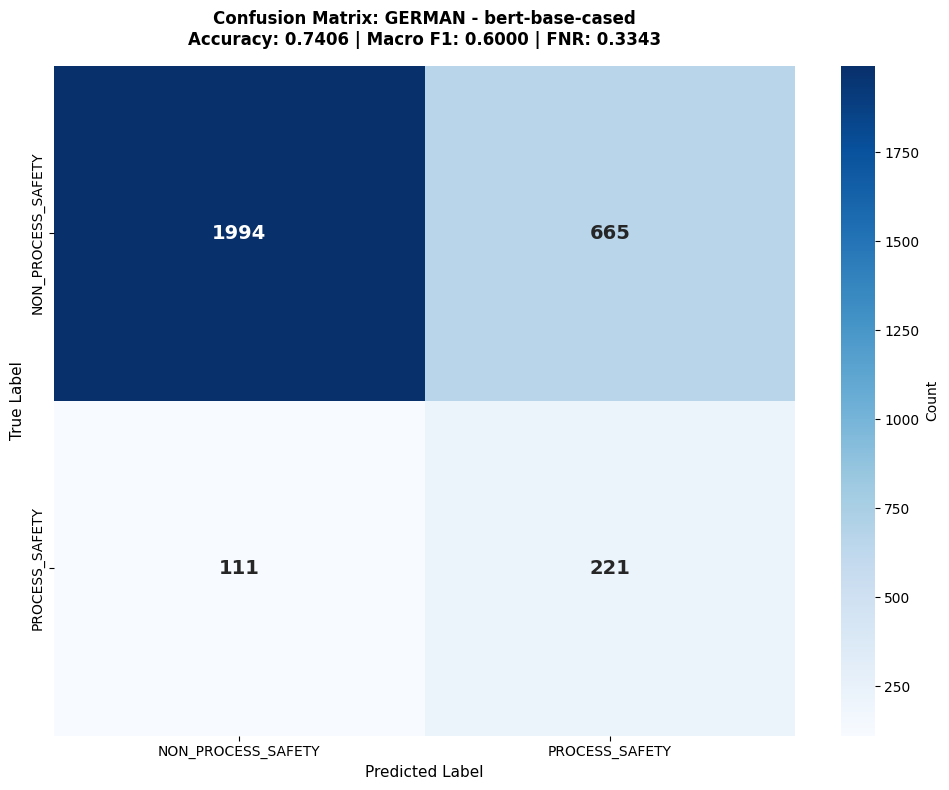

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/iter1_cm_german_bert_base_cased.png

PIPELINE COMPLETE: GERMAN

German dataset processing complete!


In [20]:
# ============================================================
# German Dataset
# ============================================================

_path = BY_SL_COUNTRY_DIR / 'master_df_Germany_manual.json'
assert _path.exists(), f"Dataset not found: {_path}"
german_df = pd.read_json(_path)

german_results = run_full_pipeline(
    df=german_df,
    dataset_name='german',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)


all_results.append(german_results)
print(f"German dataset processing complete!")

### UK Dataset Processing
This cell loads the UK dataset, runs the full BERT embedding and SVM pipeline, and appends the results for summary analysis.


STEP 1: EMBEDDINGS ALREADY EXIST - UK
 Using cached embeddings: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/uk_bert-base-cased_embeddings.pkl
  (Delete this file to regenerate embeddings)

STEP 2: TRAINING LinearSVC (FAST) - UK
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/uk_bert-base-cased_embeddings.pkl
Training samples: 3738, Test samples: 935
Applied StandardScaler to embeddings.
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 1.8 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.87      0.77      0.82       657
Process Safety       0.57      0.72      0.64       278

      accuracy                           0.76       935
     macro avg       0.72      0.75      0.73       935
  weighted avg       0.78      0.76      0.76  

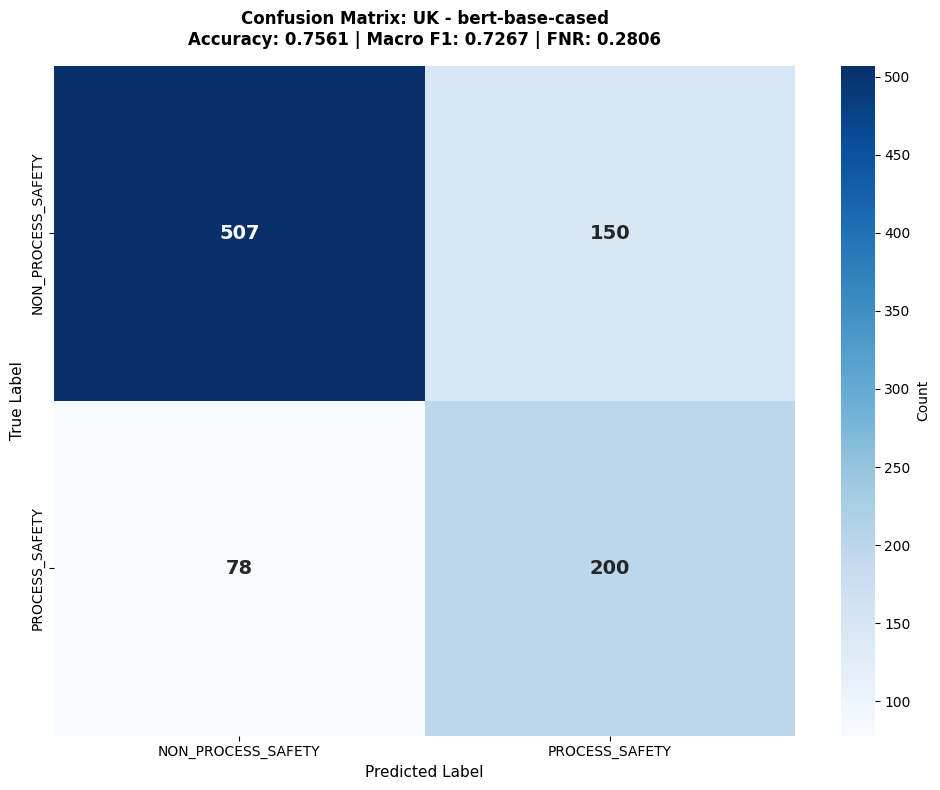

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/iter1_cm_uk_bert_base_cased.png

PIPELINE COMPLETE: UK

UK dataset processing complete!


In [21]:
# ============================================================
# UK Dataset
# ============================================================

_path = BY_SL_COUNTRY_DIR / 'master_df_UK_manual.json'
assert _path.exists(), f"Dataset not found: {_path}"
uk_df = pd.read_json(_path)

uk_results = run_full_pipeline(
    df=uk_df,
    dataset_name='uk',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)


all_results.append(uk_results)
print(f"UK dataset processing complete!")

### English Dataset Processing (UK + UAE + International)
This cell processes the combined English dataset, runs the BERT embedding and SVM pipeline, and appends the results for summary analysis.


STEP 1: EMBEDDINGS ALREADY EXIST - ENGLISH
 Using cached embeddings: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/english_bert-base-cased_embeddings.pkl
  (Delete this file to regenerate embeddings)

STEP 2: TRAINING LinearSVC (FAST) - ENGLISH
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/english_bert-base-cased_embeddings.pkl
Training samples: 3770, Test samples: 943
Applied StandardScaler to embeddings.
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 1.7 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.86      0.76      0.81       661
Process Safety       0.56      0.72      0.63       282

      accuracy                           0.75       943
     macro avg       0.71      0.74      0.72       943
  weighted avg       0.77  

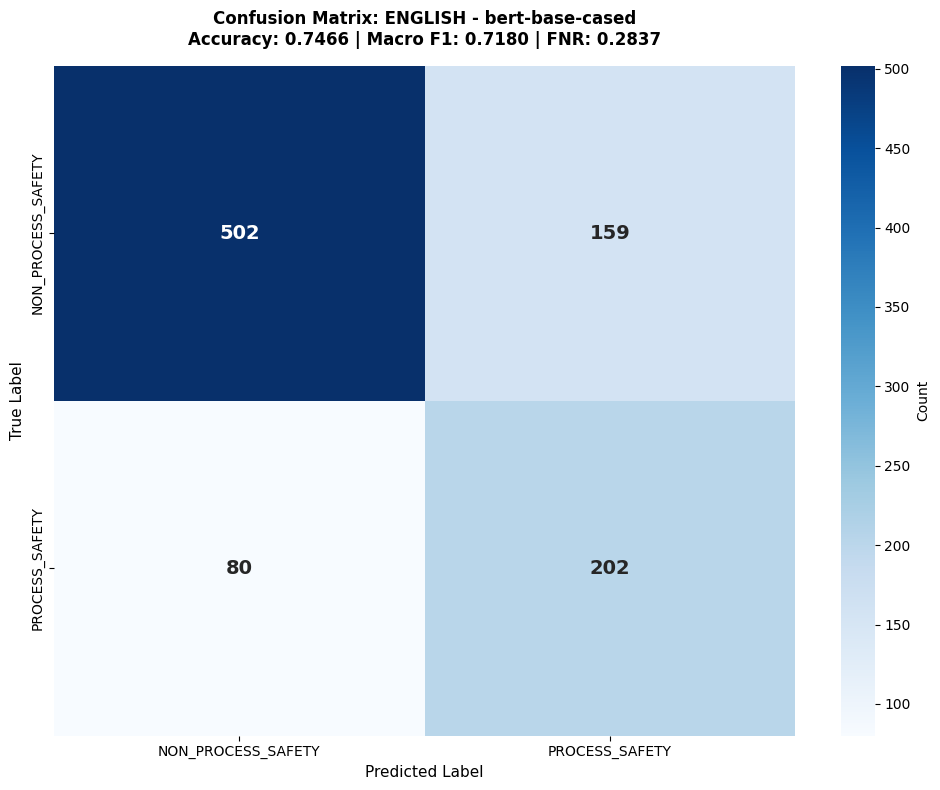

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/iter1_cm_english_bert_base_cased.png

PIPELINE COMPLETE: ENGLISH

English dataset processing complete!


In [22]:
# ============================================================
# English Dataset (UK + UAE + International)
# ============================================================

_path = BY_SL_COUNTRY_DIR / 'master_df_English_manual.json'
assert _path.exists(), f"Dataset not found: {_path}"
english_df = pd.read_json(_path)

english_results = run_full_pipeline(
    df=english_df,
    dataset_name='english',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)


all_results.append(english_results)
print(f"English dataset processing complete!")

### Sweden Dataset Processing
This cell loads the Sweden dataset, runs the full BERT embedding and SVM pipeline, and appends the results for summary analysis.


STEP 1: EMBEDDINGS ALREADY EXIST - SWEDEN
 Using cached embeddings: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/sweden_bert-base-cased_embeddings.pkl
  (Delete this file to regenerate embeddings)

STEP 2: TRAINING LinearSVC (FAST) - SWEDEN
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/sweden_bert-base-cased_embeddings.pkl
Training samples: 9779, Test samples: 2445
Applied StandardScaler to embeddings.
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 5.1 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.97      0.81      0.88      2290
Process Safety       0.17      0.59      0.26       155

      accuracy                           0.79      2445
     macro avg       0.57      0.70      0.57      2445
  weighted avg       0.92     

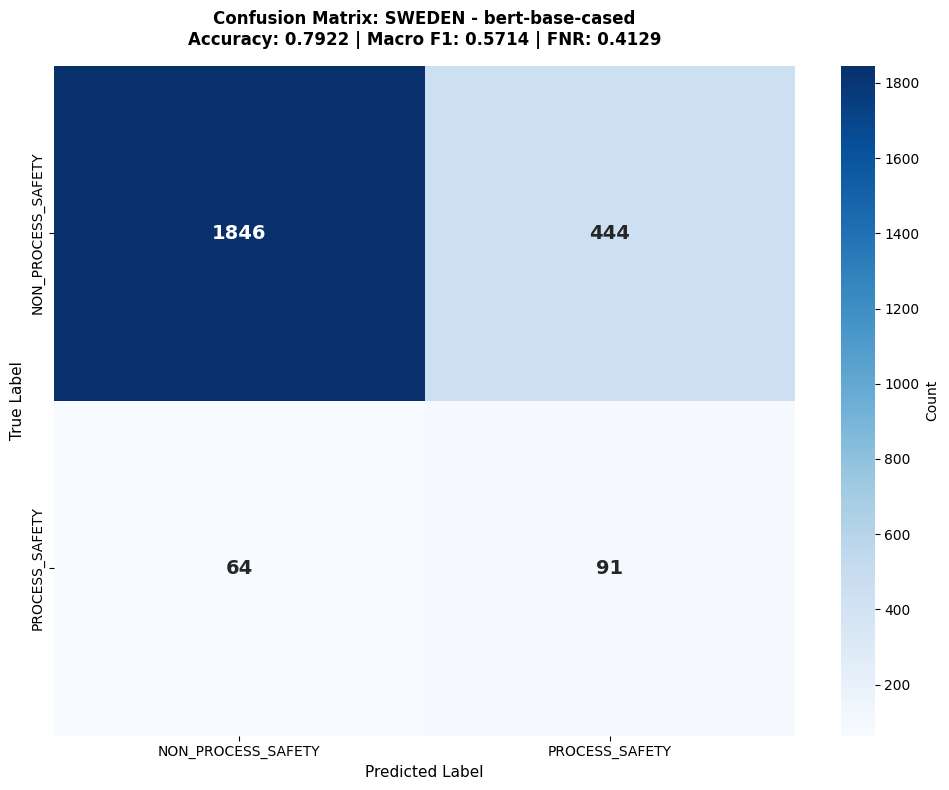

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/iter1_cm_sweden_bert_base_cased.png

PIPELINE COMPLETE: SWEDEN

Sweden dataset processing complete!


In [23]:
# ============================================================
# Sweden Dataset
# ============================================================

_path = BY_SL_COUNTRY_DIR / 'master_df_Sweden_manual.json'
assert _path.exists(), f"Dataset not found: {_path}"
sweden_df = pd.read_json(_path)

sweden_results = run_full_pipeline(
    df=sweden_df,
    dataset_name='sweden',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)


all_results.append(sweden_results)
print(f"Sweden dataset processing complete!")

### Netherlands Dataset Processing
This cell loads the Netherlands dataset, runs the full BERT embedding and SVM pipeline, and appends the results for summary analysis.


STEP 1: EMBEDDINGS ALREADY EXIST - NETHERLANDS
 Using cached embeddings: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/netherlands_bert-base-cased_embeddings.pkl
  (Delete this file to regenerate embeddings)

STEP 2: TRAINING LinearSVC (FAST) - NETHERLANDS
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/netherlands_bert-base-cased_embeddings.pkl
Training samples: 1592, Test samples: 398
Applied StandardScaler to embeddings.
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 5.0 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.78      0.75      0.76       280
Process Safety       0.46      0.51      0.48       118

      accuracy                           0.68       398
     macro avg       0.62      0.63      0.62       398
  weighted 

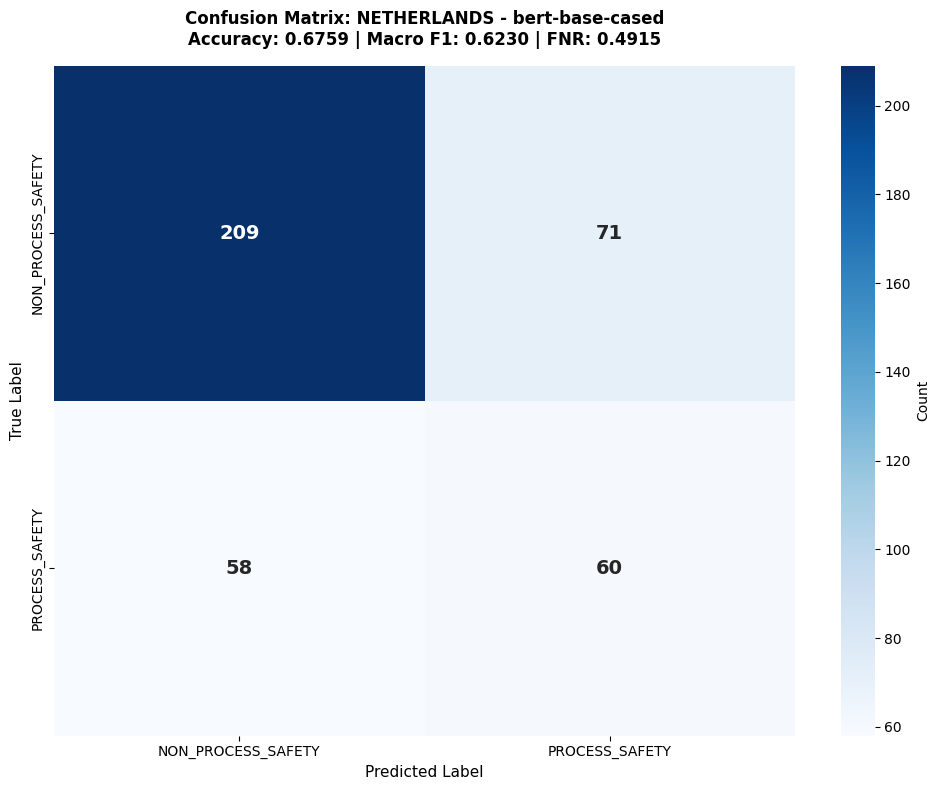

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/iter1_cm_netherlands_bert_base_cased.png

PIPELINE COMPLETE: NETHERLANDS

Netherlands dataset processing complete!


In [24]:
# ============================================================
# Netherlands Dataset
# ============================================================

_path = BY_SL_COUNTRY_DIR / 'master_df_Netherlands_manual.json'
assert _path.exists(), f"Dataset not found: {_path}"
netherlands_df = pd.read_json(_path)

netherlands_results = run_full_pipeline(
    df=netherlands_df,
    dataset_name='netherlands',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)


all_results.append(netherlands_results)
print(f"Netherlands dataset processing complete!")

### Master Dataset Processing
This cell processes the entire master dataset, runs the BERT embedding and SVM pipeline, and appends the results for summary analysis.


STEP 1: EMBEDDINGS ALREADY EXIST - MASTER_DF
 Using cached embeddings: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/master_df_bert-base-cased_embeddings.pkl
  (Delete this file to regenerate embeddings)

STEP 2: TRAINING LinearSVC (FAST) - MASTER_DF
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_1/bert-base-cased/master_df_bert-base-cased_embeddings.pkl
Training samples: 27660, Test samples: 6916
Applied StandardScaler to embeddings.
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 14.7 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.94      0.76      0.84      6004
Process Safety       0.30      0.67      0.42       912

      accuracy                           0.75      6916
     macro avg       0.62      0.72      0.63      6916
  weighted avg  

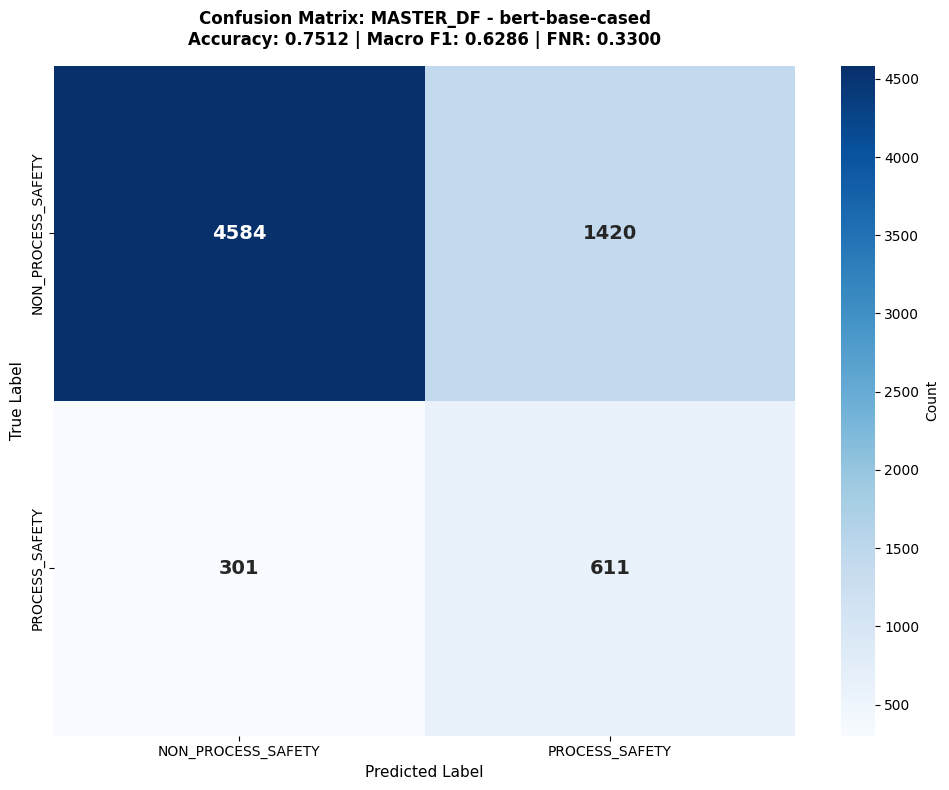

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/iter1_cm_master_df_bert_base_cased.png

PIPELINE COMPLETE: MASTER_DF


[OK] Master dataset processing complete!


In [25]:
# ============================================================
# Master Dataset
# ============================================================

assert Path(MASTER_PATH).exists(), f"Dataset not found: {MASTER_PATH}"
master_df = pd.read_json(str(MASTER_PATH))

master_results = run_full_pipeline(
    df=master_df,
    dataset_name='master_df',
    embeddings_dir=EMBEDDINGS_DIR,
    results_dir=RESULTS_DIR
)

all_results.append(master_results)
print("\n[OK] Master dataset processing complete!")

## 6. Summary Report and Analysis
This section generates a comprehensive summary report of all processed datasets, including confusion matrices, per-class metrics, error rates, class imbalance, and key observations. It also compares results with the baseline from Iteration 0 and saves summary tables for reporting and thesis documentation.

In [26]:
# ============================================================
# Generate Summary Report
# ============================================================

print(f"\n\n{'#'*100}")
print(f"{'ITERATION 1 - COMPLETE SUMMARY REPORT':^100}")
print(f"{'#'*100}\n")

# Create summary DataFrame
results_df = pd.DataFrame(all_results)

# ============================================================
# Confusion Matrix Summary
# ============================================================
print(f"\n{'CONFUSION MATRIX SUMMARY':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<15} {'TN':>10} {'FP':>10} {'FN':>10} {'TP':>10} {'Total':>12} {'Accuracy':>12} {'Macro F1':>12}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    print(f"{row['dataset'].upper():<15} {row['TN']:>10,} {row['FP']:>10,} {row['FN']:>10,} {row['TP']:>10,} {row['total']:>12,} {row['accuracy']:>12.4f} {row['macro_f1']:>12.4f}")
print(f"{'='*100}\n")

# ============================================================
# Per-Class Metrics (Classification Report Style)
# ============================================================
print(f"\n{'PER-CLASS METRICS (sklearn classification_report style)':^100}")
print(f"{'='*100}")

for _, row in results_df.iterrows():
    dataset = row['dataset'].upper()
    support_nps = row['TN'] + row['FP']  # Actual NPS samples
    support_ps = row['FN'] + row['TP']    # Actual PS samples
    total = row['total']
    
    # Weighted averages
    weighted_precision = (row['precision_nps'] * support_nps + row['precision_ps'] * support_ps) / total
    weighted_recall = (row['recall_nps'] * support_nps + row['recall_ps'] * support_ps) / total
    weighted_f1 = (row['f1_nps'] * support_nps + row['f1_ps'] * support_ps) / total
    
    # Macro averages (already have macro_f1)
    macro_precision = (row['precision_nps'] + row['precision_ps']) / 2
    macro_recall = (row['recall_nps'] + row['recall_ps']) / 2
    
    print(f"\n┌─────────────────────────────────────────────────────────────────────────────────────────────────┐")
    print(f"│ {dataset:^95} │")
    print(f"├─────────────────────────────────────────────────────────────────────────────────────────────────┤")
    print(f"│ {'Class':<20} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>12}               │")
    print(f"├─────────────────────────────────────────────────────────────────────────────────────────────────┤")
    print(f"│ {'Non-Process Safety':<20} {row['precision_nps']:>12.4f} {row['recall_nps']:>12.4f} {row['f1_nps']:>12.4f} {support_nps:>12,}               │")
    print(f"│ {'Process Safety':<20} {row['precision_ps']:>12.4f} {row['recall_ps']:>12.4f} {row['f1_ps']:>12.4f} {support_ps:>12,}               │")
    print(f"├─────────────────────────────────────────────────────────────────────────────────────────────────┤")
    print(f"│ {'Accuracy':<20} {'':>12} {'':>12} {row['accuracy']:>12.4f} {total:>12,}               │")
    print(f"│ {'Macro Avg':<20} {macro_precision:>12.4f} {macro_recall:>12.4f} {row['macro_f1']:>12.4f} {total:>12,}               │")
    print(f"│ {'Weighted Avg':<20} {weighted_precision:>12.4f} {weighted_recall:>12.4f} {weighted_f1:>12.4f} {total:>12,}               │")
    print(f"└─────────────────────────────────────────────────────────────────────────────────────────────────┘")

print(f"\n{'='*100}\n")

# ============================================================
# Detailed Metrics Summary Table
# ============================================================
print(f"\n{'DETAILED METRICS BY DATASET':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<12} {'Prec_NPS':>10} {'Rec_NPS':>10} {'F1_NPS':>10} {'Prec_PS':>10} {'Rec_PS':>10} {'F1_PS':>10} {'FPR':>10} {'FNR':>10}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    print(f"{row['dataset'].upper():<12} {row['precision_nps']:>10.4f} {row['recall_nps']:>10.4f} {row['f1_nps']:>10.4f} {row['precision_ps']:>10.4f} {row['recall_ps']:>10.4f} {row['f1_ps']:>10.4f} {row['fpr']:>10.4f} {row['fnr']:>10.4f}")
print(f"{'='*100}\n")

# ============================================================
# Error Rate Analysis
# ============================================================
print(f"\n{'ERROR RATE ANALYSIS':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<15} {'Error Rate':>12} {'FPR':>12} {'FNR':>12} {'PS Missed':>15} {'NPS Misclass.':>15}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    error_rate = 1 - row['accuracy']
    ps_missed = row['FN']  # Process Safety incidents missed (False Negatives)
    nps_misclassified = row['FP']  # Non-PS incorrectly flagged as PS (False Positives)
    print(f"{row['dataset'].upper():<15} {error_rate:>12.4f} {row['fpr']:>12.4f} {row['fnr']:>12.4f} {ps_missed:>15,} {nps_misclassified:>15,}")
print(f"{'='*100}\n")

# ============================================================
# Class Imbalance Analysis
# ============================================================
print(f"\n{'CLASS IMBALANCE ANALYSIS':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<15} {'Total':>10} {'NPS Count':>12} {'PS Count':>12} {'NPS %':>10} {'PS %':>10} {'Imbalance Ratio':>18}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    nps_count = row['TN'] + row['FP']  # Actual NPS
    ps_count = row['FN'] + row['TP']    # Actual PS
    nps_pct = (nps_count / row['total']) * 100
    ps_pct = (ps_count / row['total']) * 100
    imbalance_ratio = max(nps_count, ps_count) / min(nps_count, ps_count) if min(nps_count, ps_count) > 0 else float('inf')
    print(f"{row['dataset'].upper():<15} {row['total']:>10,} {nps_count:>12,} {ps_count:>12,} {nps_pct:>9.1f}% {ps_pct:>9.1f}% {imbalance_ratio:>17.2f}:1")
print(f"{'='*100}\n")

# ============================================================
# Key Observations
# ============================================================
print(f"\n{'KEY OBSERVATIONS':^100}")
print(f"{'='*100}")
print(f"\n  Performance Metrics:")
print(f"  • Total datasets processed: {len(results_df)}")
print(f"  • Best Macro F1: {results_df['macro_f1'].max():.4f} ({results_df.loc[results_df['macro_f1'].idxmax(), 'dataset'].upper()})")
print(f"  • Worst Macro F1: {results_df['macro_f1'].min():.4f} ({results_df.loc[results_df['macro_f1'].idxmin(), 'dataset'].upper()})")
print(f"  • Average Macro F1: {results_df['macro_f1'].mean():.4f}")
print(f"  • Average Accuracy: {results_df['accuracy'].mean():.4f}")

print(f"\n  Error Rates (Critical for Safety):")
print(f"  • Lowest FNR (best - fewest PS incidents missed): {results_df['fnr'].min():.4f} ({results_df.loc[results_df['fnr'].idxmin(), 'dataset'].upper()})")
print(f"  • Highest FNR (worst - most PS incidents missed): {results_df['fnr'].max():.4f} ({results_df.loc[results_df['fnr'].idxmax(), 'dataset'].upper()})")
print(f"  • Average FNR: {results_df['fnr'].mean():.4f}")
print(f"  • Average FPR: {results_df['fpr'].mean():.4f}")

print(f"\n  Precision-Recall Trade-off:")
best_ps_precision_idx = results_df['precision_ps'].idxmax()
best_ps_recall_idx = results_df['recall_ps'].idxmax()
print(f"  • Best PS Precision: {results_df['precision_ps'].max():.4f} ({results_df.loc[best_ps_precision_idx, 'dataset'].upper()})")
print(f"  • Best PS Recall: {results_df['recall_ps'].max():.4f} ({results_df.loc[best_ps_recall_idx, 'dataset'].upper()})")
print(f"  • Average PS Precision: {results_df['precision_ps'].mean():.4f}")
print(f"  • Average PS Recall: {results_df['recall_ps'].mean():.4f}")
print(f"{'='*100}\n")

# ============================================================
# Comparison with Baseline
# ============================================================
print(f"\n{'COMPARISON WITH ITERATION 0 BASELINE':^100}")
print(f"{'='*100}")
print(f"Iteration 0 Baseline (bert-base-uncased, manual English): Macro F1 = 0.7825")
print(f"RQ1 Target: Macro F1 ≥ 0.85 (+6.75 percentage points improvement)\n")
for _, row in results_df.iterrows():
    improvement = row['macro_f1'] - 0.7825
    status = "[OK] TARGET MET" if row['macro_f1'] >= 0.85 else "[X] Below Target"
    print(f"  {row['dataset'].upper():<15}: Macro F1 = {row['macro_f1']:.4f} (Δ = {improvement:+.4f}) {status}")

# Summary statistics
met_target = (results_df['macro_f1'] >= 0.85).sum()
print(f"\n  Summary: {met_target}/{len(results_df)} datasets met the RQ1 target (≥0.85 Macro F1)")
print(f"{'='*100}\n")

# ============================================================
# Save Results
# ============================================================
summary_file = os.path.join(RESULTS_DIR, 'iteration_1_summary.json')
results_df.to_json(summary_file, orient='records', indent=2)
print(f"Summary saved to: {summary_file}")

# ============================================================
# Section 9: Markdown Tables for LaTeX/Thesis
# ============================================================
print(f"\n\n{'MARKDOWN TABLES (for LaTeX/Thesis)':^100}")
print(f"{'='*100}\n")

print("Table 1: Confusion Matrix Summary")
display_cols = ['dataset', 'TN', 'FP', 'FN', 'TP', 'accuracy', 'macro_f1']
print(results_df[display_cols].to_markdown(index=False, floatfmt='.4f'))

print("\n\nTable 2: Per-Class Precision, Recall, F1-Score")
class_metrics_cols = ['dataset', 'precision_nps', 'recall_nps', 'f1_nps', 'precision_ps', 'recall_ps', 'f1_ps']
print(results_df[class_metrics_cols].to_markdown(index=False, floatfmt='.4f'))

print("\n\nTable 3: Error Rates")
error_cols = ['dataset', 'fpr', 'fnr']
results_df['error_rate'] = 1 - results_df['accuracy']
error_display = results_df[['dataset', 'error_rate', 'fpr', 'fnr']].copy()
print(error_display.to_markdown(index=False, floatfmt='.4f'))

print(f"\n\n{'='*100}")
print(f"{'ITERATION 1 PIPELINE COMPLETE':^100}")
print(f"{'='*100}")



####################################################################################################
                               ITERATION 1 - COMPLETE SUMMARY REPORT                                
####################################################################################################


                                      CONFUSION MATRIX SUMMARY                                      
Dataset                 TN         FP         FN         TP        Total     Accuracy     Macro F1
----------------------------------------------------------------------------------------------------
GERMAN               1,994        665        111        221        2,991       0.7406       0.6000
UK                     507        150         78        200          935       0.7561       0.7267
ENGLISH                502        159         80        202          943       0.7466       0.7180
SWEDEN               1,846        444         64         91        2,445       0.7922       0.5